In [1]:
import torch
print(torch.__version__)
print(torch.backends.mps.is_available())

2.10.0
True


In [2]:
from pathlib import Path

data_dir = Path("/Users/lucapopescu/Desktop/archive_ssi/shipsnet/shipsnet")
files = list(data_dir.glob("*.png"))

ship = [f for f in files if f.name.startswith("1")]
no_ship = [f for f in files if f.name.startswith("0")]

print(f"Total images: {len(files)}")
print(f"Ship (1): {len(ship)}")
print(f"No-ship (0): {len(no_ship)}")
print(f"Ratio: {len(no_ship)/len(ship):.1f}x more no-ship than ship")

Total images: 4000
Ship (1): 1000
No-ship (0): 3000
Ratio: 3.0x more no-ship than ship


In [3]:
from PIL import Image
import numpy as np

sample = Image.open(files[0])
print(f"Image size: {sample.size}")
print(f"Image mode: {sample.mode}")
print(f"Pixel range: {np.array(sample).min()} - {np.array(sample).max()}")

Image size: (80, 80)
Image mode: RGB
Pixel range: 55 - 255


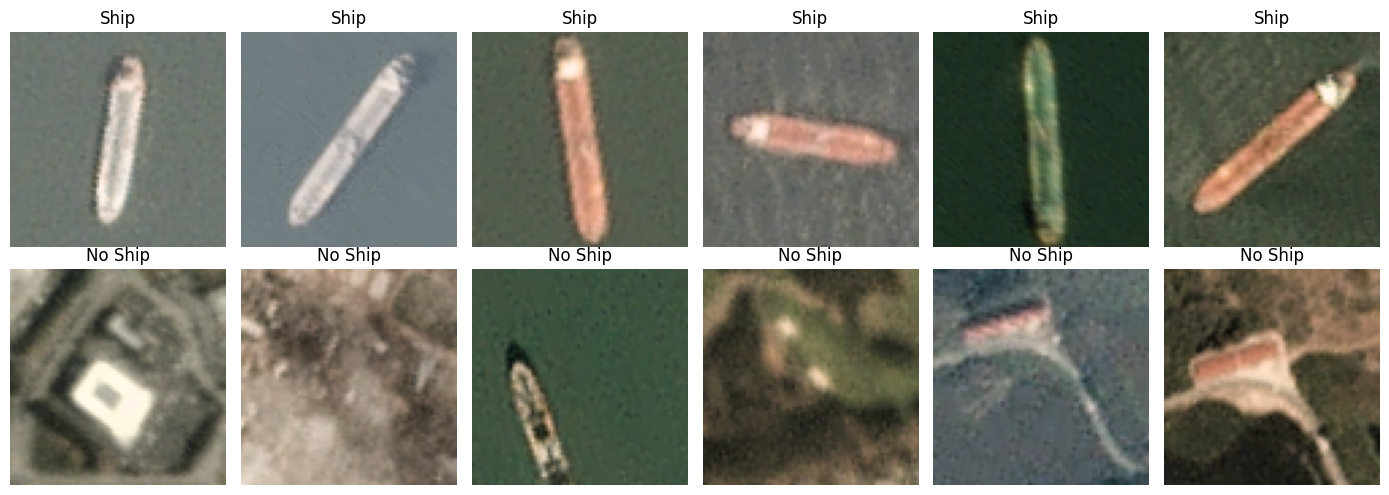

In [4]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for i, ax in enumerate(axes[0]):
    img = Image.open(random.choice(ship))
    ax.imshow(img)
    ax.set_title("Ship")
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    img = Image.open(random.choice(no_ship))
    ax.imshow(img)
    ax.set_title("No Ship")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

all_files = [str(f) for f in files]
all_labels = [int(f.name.startswith("1")) for f in files]

# Split off the test set
train_val_files, test_files, train_val_labels, test_labels = train_test_split(
    all_files, all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

# Split remaining into train and validation
train_files, val_files, train_labels, val_labels = train_test_split(
    train_val_files, train_val_labels,
    test_size=0.176,
    random_state=42,
    stratify=train_val_labels
)

print(f"Train: {len(train_files)} images")
print(f"Val:   {len(val_files)} images")
print(f"Test:  {len(test_files)} images")

Train: 2801 images
Val:   599 images
Test:  600 images


In [8]:
import sys
sys.path.append("/Users/lucapopescu/Desktop/SSI")

from torchvision import transforms
from dataloader import load_shipsnet

# ImageNet normalization
imagenet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_loader, val_loader, test_loader = load_shipsnet(
    data_dir="/Users/lucapopescu/Desktop/archive_ssi",
    transform=imagenet_transform
)

Train: 2800 | Val: 600 | Test: 600


In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn

# Load pretrained ResNet-18
model = models.resnet18(weights='IMAGENET1K_V1')

# Replace the final fully connected layer
# ResNet-18's final layer outputs 512 -> 1000 (ImageNet classes)
# Replace with 512 -> 1 for binary classification
model.fc = nn.Linear(model.fc.in_features, 1)

device = torch.device("mps")
model = model.to(device)

print(model.fc)
print(f"Model is on: {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/lucapopescu/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:08<00:00, 5.64MB/s]


Linear(in_features=512, out_features=1, bias=True)
Model is on: mps:0


In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Loss function
# pos_weight handles the 3:1 class imbalance
pos_weight = torch.tensor([3.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer
optimizer = Adam(model.parameters(), lr=1e-4)

# Scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

print("Loss, optimizer and scheduler ready")

Loss, optimizer and scheduler ready


In [12]:
NUM_EPOCHS = 10

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # --- Validation phase ---
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)

    # Step the scheduler
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/Users/lucapopescu/Desktop/SSI/best_model.pth")

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("Training complete!")

Epoch 1/10 | Train Loss: 0.2324 | Val Loss: 0.0629
Epoch 2/10 | Train Loss: 0.0367 | Val Loss: 0.0309
Epoch 3/10 | Train Loss: 0.0127 | Val Loss: 0.0244
Epoch 4/10 | Train Loss: 0.0063 | Val Loss: 0.0181
Epoch 5/10 | Train Loss: 0.0033 | Val Loss: 0.0187
Epoch 6/10 | Train Loss: 0.0073 | Val Loss: 0.0380
Epoch 7/10 | Train Loss: 0.0064 | Val Loss: 0.0147
Epoch 8/10 | Train Loss: 0.0074 | Val Loss: 0.0213
Epoch 9/10 | Train Loss: 0.0226 | Val Loss: 0.0174
Epoch 10/10 | Train Loss: 0.0117 | Val Loss: 0.0203
Training complete!


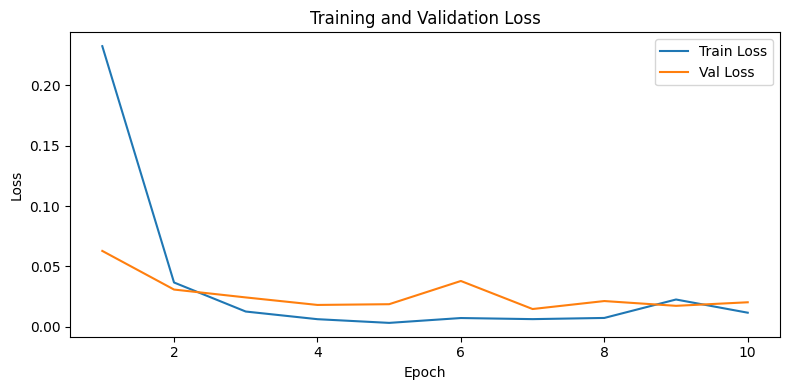

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label='Train Loss')
plt.plot(range(1, NUM_EPOCHS+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best saved model
model.load_state_dict(torch.load("/Users/lucapopescu/Desktop/SSI/best_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= 0.5).long()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(classification_report(all_labels, all_preds, target_names=['No Ship', 'Ship']))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

     No Ship       1.00      0.99      0.99       450
        Ship       0.97      1.00      0.98       150

    accuracy                           0.99       600
   macro avg       0.98      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

Confusion Matrix:
[[445   5]
 [  0 150]]
